## Redes Convolucionales
#### Ejemplo clasificación de perros y gatos para CAPTCHA

Este notebook utiliza datos de la [competición de Kaggle Dogs vs. Cats](https://www.kaggle.com/c/dogs-vs-cats/overview). En esta competicion se utiliza Asirra (Animal Species Image Recognition for Restricting Access), CAPTCHA que sirve para diferenciar entre una persona o una máquina accediendo a una página web. Este tipo de "pruebas" se utilizan para evitar emails de spam, y ataques por fuerza bruta contra servidores.

En este notebook vamos a probar que hay técnicas de clasificado automáticas de imágenes mediante redes neuronales, que con las que se intenta saltar CAPTCHA

In [ ]:
#%pip install scikit-image opencv-python 
# numpy pandas scikit-learn matplotlib keras seaborn tensorflow

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.2/11.9 MB 4.0 MB/s eta 0:00:03
   --- ------------------------------------ 1.0/11.9 MB 10.8 MB/s eta 0:00:02
   --------- ------------------------------ 2.8/11.9 MB 20.3 MB/s eta 0:00:01
   ---------- ----------------------------- 3.0/11.9 MB 17.5 MB/s eta 0:00:01
   ------------------ --------------------- 5.5/11.9 MB 23.6 MB/s eta 0:00:01
   -------------------- ------------------- 6.1/11.9 MB 21.8 MB/s eta 0:00:01
   ------------------------- -------------- 7.6/11.9 MB 23.2 MB/s eta 0:00:01
   ------------------------------ --------- 9.0/11.9 MB 26.1 MB/s eta 0:00:01
   ------------------------------------ --- 10.9/11.9 MB 29.8 MB/s eta 0:00:01
   ---------------------------------------  11.6/11.9 MB 31.2 MB/s eta 0:00:01
   ---------------------------------------  11.6/11.9 MB 31.2 MB/s eta 0:00:01
   ---------------------------------------  11.7/11.9 MB 25.2 MB/s eta


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import Library

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os

# Define Constants
Tendremos una serie de constantes como las dimensiones de las imágenes, que serán fijas a lo largo de todo el notebook

In [2]:
IMAGE_WIDTH=32
IMAGE_HEIGHT=32
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 32
EPOCHS = 30

# Prepare Training Data
1. Descárgate el dataset desde [aquí](https://drive.google.com/drive/folders/1WUIVV96pTy1SpL-qMenh3UtgDAEY9hNh?usp=sharing)
2. Descomprime el dataset y guardalo en la ruta que quieras del ordenador.
3. En este punto vamos guardar en una lista las etiquetas de cada foto.

In [3]:
ROOT_PATH = r"C:\\Users\\NaiaJon\\Documents\\Naia\\BootcampDataScience\\Datos clase grandes\\"

TRAIN_PATH = ROOT_PATH+ r"train\\"
TEST_PATH = ROOT_PATH + r"test\\"

In [ ]:
##### CODE #####

# Listar todos los archivos de la carpeta de train (TRAIN_PATH)
filenames = os.listdir(TRAIN_PATH)

# Lista vacia
categories = []

# Iterar
for filename in filenames:
    # Saco el nombre
    category = filename.split('.')[0]
    
    # If else
    # Guardo en lista
    if category == 'dog':
        categories.append(1)
    else:
        categories.append(0)
    
    
df = pd.DataFrame({
    'filename': filenames,
    'category': categories
}) 

In [5]:
df.sample(5)

,filename,category
2712,cat.331.jpg,0
3483,cat.513.jpg,0
2518,cat.3135.jpg,0
1746,cat.2440.jpg,0
2589,cat.32.jpg,0


### See Total In count

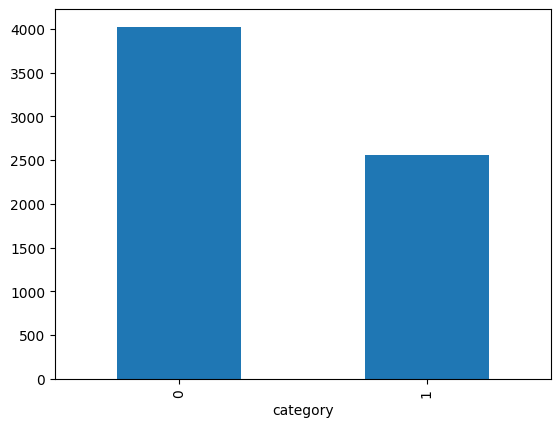

In [17]:
df['category'].value_counts().plot.bar();

# See sample image

(407, 499, 3)
255


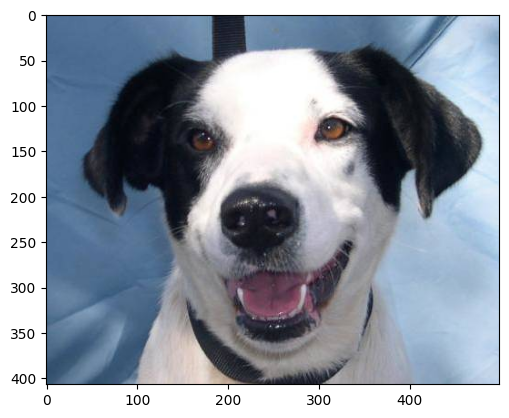

In [8]:
from skimage.io import imread
import cv2

sample = random.choice(filenames)
image = imread(TRAIN_PATH + sample)

print(image.shape)
print(np.max(image))
plt.imshow(image);

Una imagen no es mas que un array de HxWxC píxeles, siendo H(Height) y W(Width) las dimensiones de resolución de la imagen, y C el número de canales. Habrá tres valores por píxel. 

In [19]:
image

array([[[ 96, 107, 109],
        [100, 111, 113],
        [102, 113, 115],
        ...,
        [123, 126, 131],
        [123, 126, 131],
        [125, 128, 133]],

       [[ 97, 108, 110],
        [101, 112, 114],
        [103, 114, 116],
        ...,
        [120, 123, 128],
        [121, 124, 129],
        [122, 125, 130]],

       [[105, 116, 118],
        [111, 122, 124],
        [113, 124, 126],
        ...,
        [117, 120, 125],
        [117, 120, 125],
        [119, 122, 127]],

       ...,

       [[ 14,  31,  15],
        [ 14,  31,  15],
        [ 17,  34,  18],
        ...,
        [  5,  10,   4],
        [  5,  10,   4],
        [  6,  11,   5]],

       [[ 27,  44,  28],
        [ 15,  32,  16],
        [  6,  23,   7],
        ...,
        [  8,  13,   7],
        [  8,  13,   7],
        [  8,  13,   7]],

       [[ 31,  48,  32],
        [ 15,  32,  16],
        [  3,  20,   4],
        ...,
        [ 15,  20,  14],
        [ 15,  20,  14],
        [ 15,  20,  14]]

# Resize image
Cargar todas las imágenes a la vez es un problema ya que son un total de 25000 (unos 500MB la carpeta de train). Este proceso require mucha memoria, por lo que tendremos que aplicarle un resize a cada imagen para bajarlas de resolución. Esto también nos sirve para solventar el problema de tener imágenes con distintas resoluciones.

Tamaño imagen original: (375, 499, 3)
Tamaño imagen reshape: (32, 32, 3)


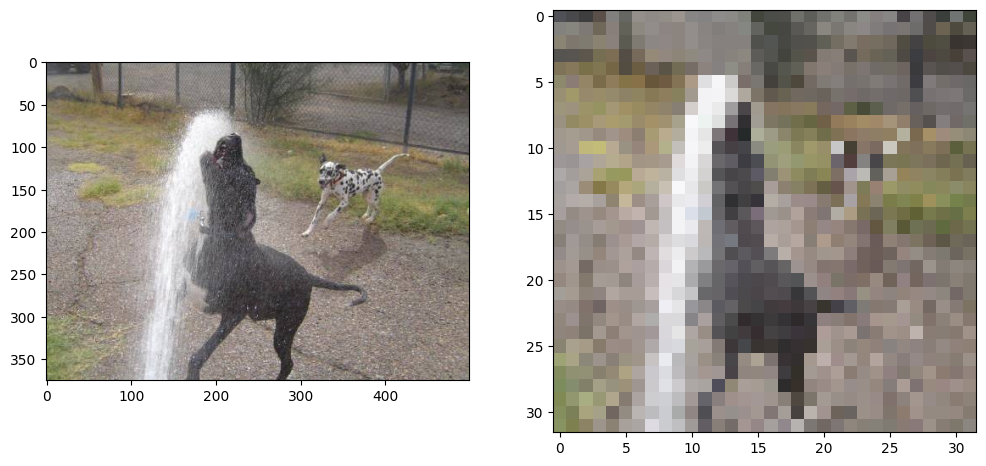

In [20]:
plt.figure(figsize=(12, 12))

sample = random.choice(filenames)
image = imread(TRAIN_PATH + sample)
imagesmall = cv2.resize(image, (IMAGE_WIDTH, IMAGE_HEIGHT))

print("Tamaño imagen original:", image.shape)
print("Tamaño imagen reshape:", imagesmall.shape)

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image)

# Resized image
plt.subplot(1, 2, 2)
plt.imshow(imagesmall);

# Color
Podríamos cargar las imágenes como blanco y negro, de esta forma se reduciría el espacio de features considerablemente al contar con un único canal

Tamaño imagen original: (463, 500)


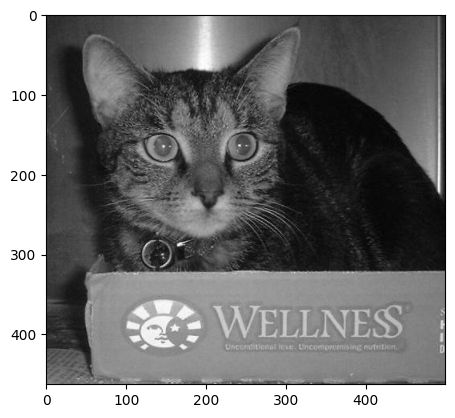

In [21]:
sample = random.choice(filenames)

image = cv2.imread(filename = TRAIN_PATH + sample, flags = cv2.IMREAD_GRAYSCALE)

print("Tamaño imagen original:", image.shape)
plt.imshow(image, cmap='gray');

# Load data
Llega el momento de cargar los datos. Ya no estan sencillo como cuando teníamos datasets en CSVs puesto que ahora hay que cargar miles de archivos en memoria en este notebook. Para ello necesitaremos un programa iterativo que vaya recorriendo los archivos de la carpeta, cargarlos como array de numpy y almacenarlos en un objeto.

In [ ]:
def read_data(path, im_size):
    X = []
    Y = []

    ##### CODE #####
    # Iterar sobre todo lo que haya en path
    for file in os.listdir(path):
        
        # Leer la imagen a color y aplicarle el resize
        image = imread(path + file)
        smallimage = cv2.resize(image, (im_size, im_size))
        
        # No se ha pasado a blanco y negro (decisión, podría hacerse)
        
        # Guardo en X
        X.append(smallimage)
        
        category = file.split('.')[0]
        # Miro si es perro y gato para guardar en Y
        if category == 'dog':
            Y.append(1)
        else:
            Y.append(0)
        

    return np.array(X), np.array(Y)


In [9]:
X_train, y_train = read_data(TRAIN_PATH, IMAGE_WIDTH)
X_test, y_test = read_data(TEST_PATH, IMAGE_WIDTH)

print(X_train.shape)
print(X_test.shape)

(6576, 32, 32, 3)
(3456, 32, 32, 3)


In [10]:
os.listdir(TRAIN_PATH)[1]

'cat.1.jpg'

(32, 32, 3)


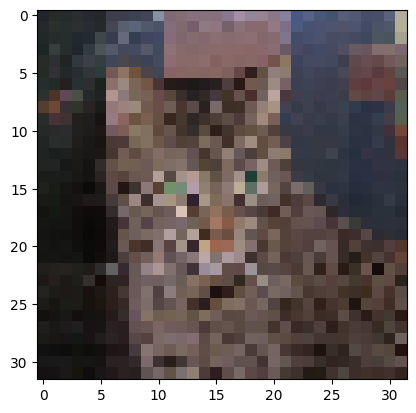

In [11]:
print(X_train[1].shape)
plt.imshow(X_train[1]);

In [12]:
X_train[0]

array([[[210, 171,  93],
        [224, 181, 103],
        [235, 192, 114],
        ...,
        [253, 227, 157],
        [250, 218, 143],
        [245, 208, 127]],

       [[212, 168,  95],
        [221, 177, 102],
        [230, 186, 111],
        ...,
        [250, 231, 162],
        [250, 218, 143],
        [244, 215, 137]],

       [[212, 168,  95],
        [220, 176, 101],
        [222, 178, 103],
        ...,
        [249, 230, 161],
        [251, 219, 144],
        [249, 219, 147]],

       ...,

       [[173, 136,  65],
        [176, 139,  68],
        [173, 139,  65],
        ...,
        [ 10,  10,   2],
        [ 11,  10,   5],
        [  9,   8,   3]],

       [[166, 132,  61],
        [173, 136,  65],
        [174, 140,  68],
        ...,
        [  5,   6,   1],
        [  4,   5,   0],
        [  4,   5,   0]],

       [[158, 126,  57],
        [166, 131,  60],
        [173, 139,  67],
        ...,
        [  4,   4,   1],
        [  3,   3,   1],
        [  3,   3,   1]]

# Normalized data
Normalizar los datos hará que entrene mucho mejor la red, al estar todos los pixeles en la misma escala.

In [13]:
print("Min:", np.min(X_train))
print("Max:", np.max(X_train))

Min: 0
Max: 255


In [14]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min:", np.min(X_train))
print("Max:", np.max(X_train))

Min: 0.0
Max: 1.0


# Shuffle data
Como hemos cargado los datos de manera ordenada (primero gatos y luego perros), tendremos que desordenarlos para asegurarnos de que no haya ningún sesgo en el entrenamiento ni en la selección de datos de validación.

In [15]:
from sklearn.utils import shuffle
# En este caso tengo las fotos ordenadas: primero gatos y luego perros. Si se las paso en ese orden aprenderá del orden
# Hago shuffle para que me las desordene
X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [16]:
X_train

array([[[[0.04705882, 0.07058824, 0.05490196],
         [0.23529412, 0.2745098 , 0.24313725],
         [0.05490196, 0.09803922, 0.08235294],
         ...,
         [0.07843137, 0.13333333, 0.13333333],
         [0.09019608, 0.12941176, 0.1254902 ],
         [0.08235294, 0.12156863, 0.11764706]],

        [[0.0745098 , 0.09411765, 0.07843137],
         [0.3254902 , 0.36862745, 0.3372549 ],
         [0.07058824, 0.11764706, 0.10196078],
         ...,
         [0.13333333, 0.17254902, 0.16862745],
         [0.12156863, 0.16470588, 0.17254902],
         [0.11372549, 0.15294118, 0.14901961]],

        [[0.09803922, 0.11764706, 0.10196078],
         [0.36470588, 0.40784314, 0.37647059],
         [0.10588235, 0.15294118, 0.1372549 ],
         ...,
         [0.18823529, 0.22745098, 0.22352941],
         [0.15686275, 0.2       , 0.20784314],
         [0.15686275, 0.18823529, 0.20784314]],

        ...,

        [[0.04705882, 0.0627451 , 0.05882353],
         [0.08627451, 0.10196078, 0.09803922]

# Save data
Podemos guardar los arrays de numpy en un archivo `.npz`, de tal manera que luego sea más rápido importarlo

In [ ]:
# Me lo guardo como array de numpy. Para tener hecho todo lo anterior que tiene carga computacional

np.savez(ROOT_PATH + '/data.npz',
        X_train = X_train,
        y_train = y_train,
        X_test = X_test,
        y_test = y_test)

In [18]:
ROOT_PATH

'C:\\\\Users\\\\NaiaJon\\\\Documents\\\\Naia\\\\BootcampDataScience\\\\Datos clase grandes\\\\'

Para cargar

In [ ]:
# Si quiero volver a cargarlas 
data = np.load(ROOT_PATH + '/data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']


# Build Model

<img src="https://i.imgur.com/ebkMGGu.jpg" width="100%"/>

* **Conv Layer**: extraerá diferentes features de las imagenes
* **Pooling Layer**: Reduce las dimensiones de las imágenes tras una capa convolucional
* **Fully Connected Layer**: Tras las capas convolucionales, aplanamos las features y las introducimos como entrada de una red neuronal normal.
* **Output Layer**: Las predicciones de la red

Para el loss y la metrica, se puede usar un binary_crossentropy, al ser un target binario.

In [ ]:
IMAGE_SIZE

In [20]:
from tensorflow import keras

layers = [
    #convolucion (64 neuronas y 3x3 en este caso) seguido de pooling
    keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=IMAGE_SIZE), 
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    # es 1 para clasificación binaria. A diferencia de regresión SI tiene función de activación
    keras.layers.Dense(1, activation='sigmoid') 
]

model = keras.Sequential(layers)

model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,921 (2.57 MB)

 Trainable params: 673,921 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

# Callbacks
#### Early Stopping

In [ ]:
from keras.callbacks import EarlyStopping
# si en 10 epochs no ha mejorado
earlystop = EarlyStopping(patience=10)

In [ ]:
from keras.callbacks import ModelCheckpoint
# para que vaya guardando en 'callback_model.keras'  segun ejecuta por si el ordenador peta. Podría volver a cargar 
# el modelo 
mcheckpoint = ModelCheckpoint("callback_model.keras")

# Fit the model

In [24]:
history = model.fit(X_train,
         y_train,
         epochs = EPOCHS,
         batch_size = BATCH_SIZE,
         callbacks = [earlystop, mcheckpoint],
         validation_split = 0.2)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6118 - loss: 0.6683 - val_accuracy: 0.5980 - val_loss: 0.6487
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6633 - loss: 0.6156 - val_accuracy: 0.6900 - val_loss: 0.5778
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7093 - loss: 0.5762 - val_accuracy: 0.6877 - val_loss: 0.5804
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7506 - loss: 0.5181 - val_accuracy: 0.7340 - val_loss: 0.5432
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7633 - loss: 0.4865 - val_accuracy: 0.7409 - val_loss: 0.5233
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7943 - loss: 0.4425 - val_accuracy: 0.7059 - val_loss: 0.6219
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8167 - loss: 0.3991 - val_accuracy: 0.7530 - val_loss: 0.5171
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8485 - loss: 0.3430 - val_accu

In [ ]:
results = model.evaluate(X_test, y_test)
print("test loss, test acc:", results)
# accuracy de 0.72

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7245 - loss: 1.3492
test loss, test acc: [1.3492380380630493, 0.7245370149612427]


<Axes: >

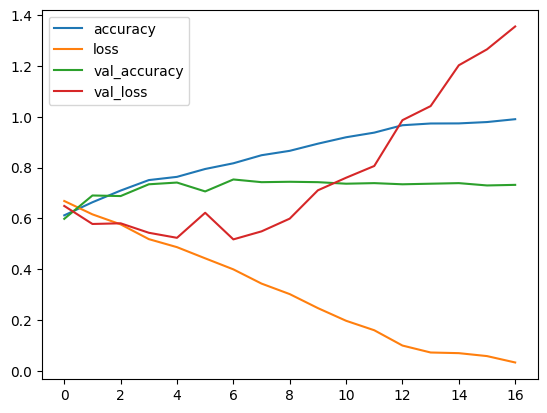

In [26]:
pd.DataFrame(history.history).plot()

In [ ]:
# El accuracy en train sigue mejorando pero en validación no: riesgo de estar en overfitting 
# De hecho la función loss está subiendo en validación

In [27]:
pd.DataFrame(history.history).head(10)

,accuracy,loss,val_accuracy,val_loss
0,0.611787,0.668264,0.598024,0.648696
1,0.663308,0.615602,0.689970,0.577772
2,0.709316,0.576242,0.687690,0.580407
3,0.750570,0.518123,0.734043,0.543173
4,0.763308,0.486489,0.740881,0.523254
5,0.794297,0.442505,0.705927,0.621890
6,0.816730,0.399061,0.753040,0.517118
7,0.848479,0.343017,0.742401,0.548690
8,0.865779,0.301657,0.743921,0.598795
9,0.893916,0.246494,0.742401,0.710376


# Evaluate
Probemos los datos en el conjunto de test.

In [28]:
results = model.evaluate(X_test, y_test)
results

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7245 - loss: 1.3492


[1.3492380380630493, 0.7245370149612427]

In [29]:
model.predict(X_test).round(0)

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


array([[0.],
       [1.],
       [0.],
       ...,
       [0.],
       [1.],
       [0.]], shape=(3456, 1), dtype=float32)

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, model.predict(X_test).round(0))
# Filas lo que es
# columnas lo que ha predicho

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


array([[1325,  323],
       [ 629, 1179]])

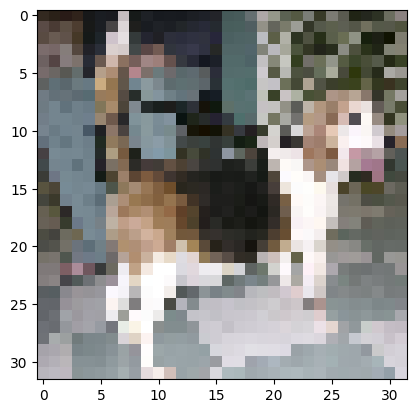

In [31]:
plt.imshow(X_test[-3]);

In [32]:
X_test[-4:-3]

array([[[[0.45882353, 0.43529412, 0.38823529],
         [0.54117647, 0.50588235, 0.4745098 ],
         [0.57254902, 0.53333333, 0.50196078],
         ...,
         [0.63137255, 0.58039216, 0.52156863],
         [0.6627451 , 0.58431373, 0.54117647],
         [0.53333333, 0.4627451 , 0.41568627]],

        [[0.48627451, 0.45098039, 0.41568627],
         [0.50588235, 0.46666667, 0.43137255],
         [0.56862745, 0.51372549, 0.47843137],
         ...,
         [0.49803922, 0.44313725, 0.3254902 ],
         [0.63137255, 0.56078431, 0.48235294],
         [0.58823529, 0.52156863, 0.45098039]],

        [[0.54901961, 0.49803922, 0.4745098 ],
         [0.55294118, 0.49803922, 0.4627451 ],
         [0.56470588, 0.50196078, 0.45098039],
         ...,
         [0.51372549, 0.44313725, 0.31764706],
         [0.65490196, 0.58039216, 0.51764706],
         [0.59607843, 0.52941176, 0.47058824]],

        ...,

        [[0.47058824, 0.42745098, 0.41568627],
         [0.45098039, 0.40784314, 0.39215686]

In [ ]:
predictions = model.predict(X_test[-4:-3])
predictions

# Nos da probabilidad de clase positiva (1) que es perro
# Está un poco confundido 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[0.08300261]], dtype=float32)

# Image data generator

In [34]:
df["category"] = df["category"].replace({0: 'cat', 1: 'dog'})

print("Categorias:", df['category'].unique())
df.head()

Categorias: ['cat' 'dog']


,filename,category
0,cat.0.jpg,cat
1,cat.1.jpg,cat
2,cat.10.jpg,cat
3,cat.100.jpg,cat
4,cat.1000.jpg,cat


In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

example_df = df.sample(n=1).reset_index(drop=True)
example_df

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 15,
    shear_range = 0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range = 0.1,
    height_shift_range = 0.1
)

example_generator = train_datagen.flow_from_dataframe(
    example_df,
    TRAIN_PATH,
    x_col = 'filename',
    y_col = 'category',
    target_size = (128, 128)
)

Found 1 validated image filenames belonging to 1 classes.


In [36]:
example_df

,filename,category
0,dog.10195.jpg,dog


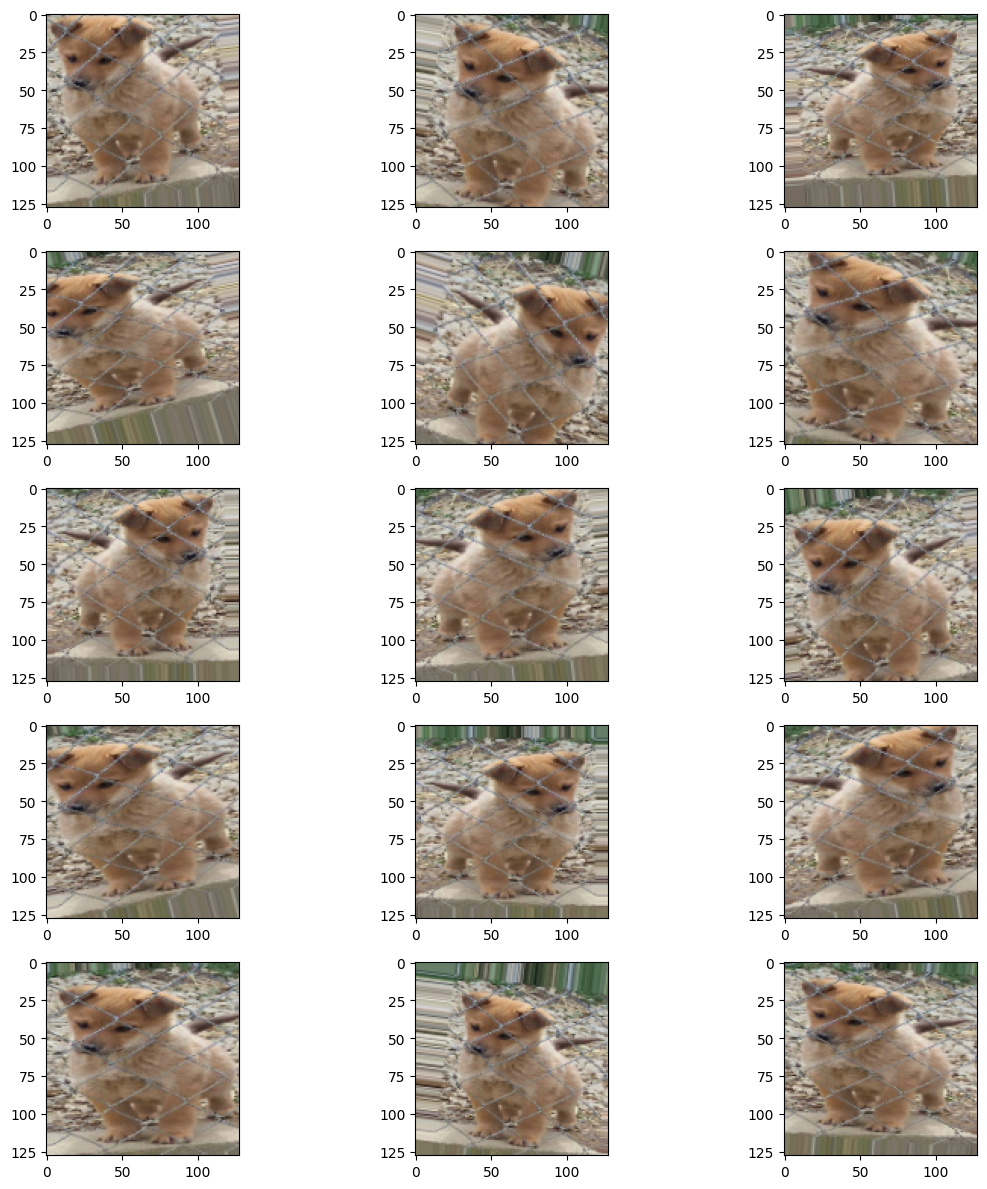

In [ ]:


plt.figure(figsize=(12, 12))

for i in range(0, 15):
    plt.subplot(5, 3, i+1)
    for X_batch, Y_batch in example_generator:
        image = X_batch[0]
        plt.imshow(image)
        break
plt.tight_layout()
plt.show()

In [ ]:
# Training generator: enriquezco el dataset modificando las imágenes: descentrándolas, haciendo algo de zoom, 
# invirtiéndolas, distorsiona... para que no aprenda de posiciones etc y ayude a generalizar

# Training Generator

In [38]:
train_df, validate_df = train_test_split(df,
                                         test_size=0.20,
                                         random_state=42)

train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

In [39]:
total_train = train_df.shape[0]
total_validate = validate_df.shape[0]

print("Shape train", total_train)
print("Shape validation", total_validate)
validate_df.head()

Shape train 5260
Shape validation 1316


,filename,category
0,cat.1419.jpg,cat
1,dog.10421.jpg,dog
2,cat.2146.jpg,cat
3,dog.11562.jpg,dog
4,cat.3654.jpg,cat


In [40]:
train_df.head()

,filename,category
0,cat.3337.jpg,cat
1,dog.12039.jpg,dog
2,cat.2542.jpg,cat
3,dog.10283.jpg,dog
4,dog.10384.jpg,dog


In [ ]:
# Coge una imagen
# Le aplica cambios aleatorios (rotar, mover, zoom…)
# Devuelve una versión “ligeramente distinta”

# Aquí generamos el objeto 'transformador'
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 15,
    shear_range = 0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range = 0.1,
    height_shift_range = 0.1
)

# Aquí ya cargo las imágenes
# puede ser a) Desde arrays con flow: train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
#b) Desde carpetas:

train_generator = train_datagen.flow_from_directory('data/train')
train_generator = train_datagen.flow_from_dataframe(
    train_df, 
    TRAIN_PATH, 
    x_col='filename',
    y_col='category',
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    class_mode='binary',
    batch_size=BATCH_SIZE
)

Found 5260 validated image filenames belonging to 2 classes.


### Validation Generator

In [43]:
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_dataframe(
    validate_df, 
    TRAIN_PATH, 
    x_col='filename',
    y_col='category',
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    class_mode='binary',
    batch_size=BATCH_SIZE
)

Found 1316 validated image filenames belonging to 2 classes.


# Fit Model

In [44]:
model = keras.Sequential(layers)

model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

In [45]:
history = model.fit(
    train_generator,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data = validation_generator
)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.6973 - loss: 0.6057 - val_accuracy: 0.8374 - val_loss: 0.3790
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7432 - loss: 0.5209 - val_accuracy: 0.9043 - val_loss: 0.2755
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.7584 - loss: 0.5026 - val_accuracy: 0.8815 - val_loss: 0.3191
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.7719 - loss: 0.4896 - val_accuracy: 0.8746 - val_loss: 0.3338
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.7660 - loss: 0.4784 - val_accuracy: 0.7804 - val_loss: 0.4287
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.7819 - loss: 0.4653 - val_accuracy: 0.8533 - val_loss: 0.3430
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.7835 - loss: 0.4622 - val_accuracy: 0.7272 - val_loss: 0.5392
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.7812 - loss: 0.4621 - val_acc

<Axes: >

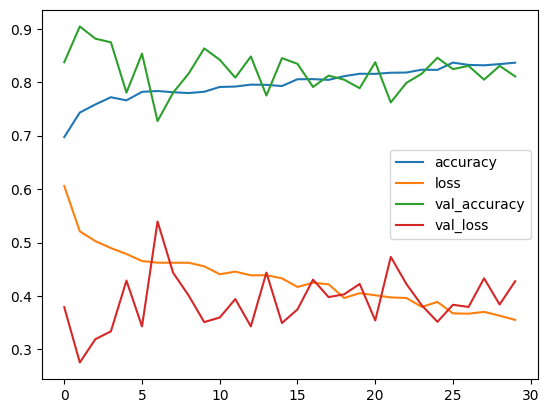

In [46]:
pd.DataFrame(history.history).plot()

In [47]:
##### CODE #####

# Listar todos los archivos de la carpeta de train (TEST_PATH)
filenames = os.listdir(TEST_PATH)

# Lista vacia
categories = []

# Iterar
for filename in filenames:
    # Saco el nombre
    category = filename.split('.')[0]
    
    # If else
    # Guardo en lista
    if category == 'dog':
        categories.append('dog')
    else:
        categories.append('cat')
    
    
test_df = pd.DataFrame({
    'filename': filenames,
    'category': categories
}) 

In [48]:
test_df

,filename,category
0,cat.10704.jpg,cat
1,cat.10705.jpg,cat
2,cat.10706.jpg,cat
3,cat.10707.jpg,cat
4,cat.10708.jpg,cat
...,...,...
3451,dog.9896.jpg,dog
3452,dog.9897.jpg,dog
3453,dog.9898.jpg,dog
3454,dog.9899.jpg,dog


In [ ]:
# También cambia las imagenes de test

In [49]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    test_df, 
    TEST_PATH, 
    x_col='filename',
    y_col='category',
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    class_mode='binary',
    batch_size=BATCH_SIZE
)

Found 3456 validated image filenames belonging to 2 classes.


In [50]:
len(test_generator)

108

In [51]:
results = model.evaluate(test_generator)
print("test loss, test acc:", results)

108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7948 - loss: 0.4797
test loss, test acc: [0.47966232895851135, 0.7948495149612427]


In [52]:
results = model.evaluate(X_test, y_test)
print("test loss, test acc:", results)

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8015 - loss: 0.4643
test loss, test acc: [0.4643099308013916, 0.8015046119689941]


# Virtualize Training

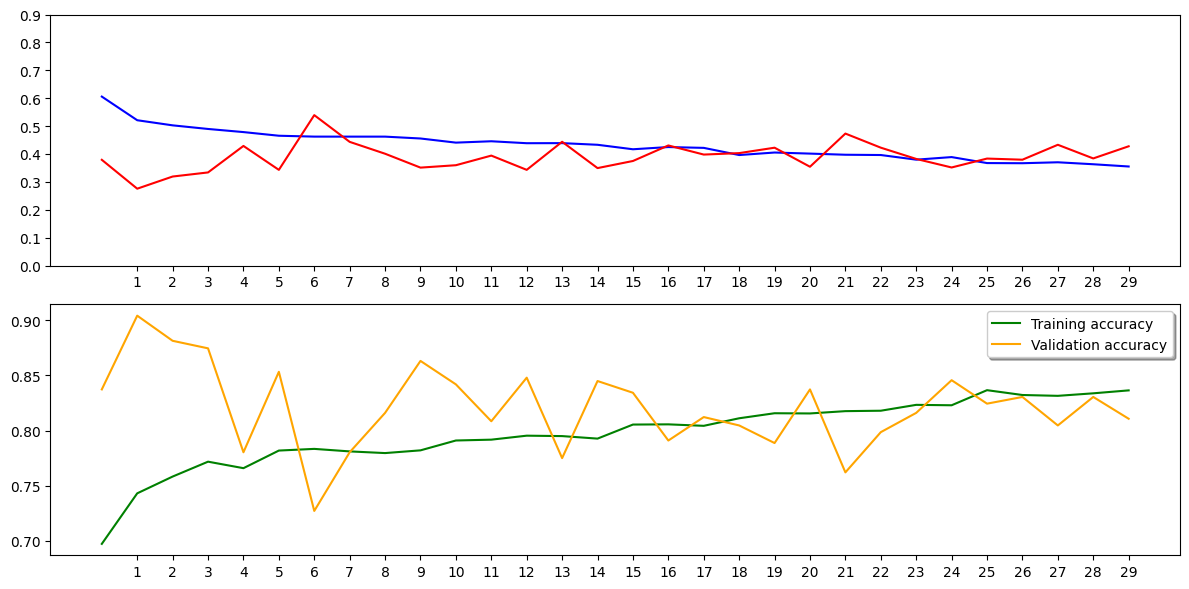

In [53]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.plot(history.history['loss'], color='b', label="Training loss")
ax1.plot(history.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(1, EPOCHS, 1))
ax1.set_yticks(np.arange(0, 1, 0.1))

ax2.plot(history.history['accuracy'], color='g', label="Training accuracy")
ax2.plot(history.history['val_accuracy'], color='orange',label="Validation accuracy")
ax2.set_xticks(np.arange(1, EPOCHS, 1))

plt.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()